# Lab 5: Regular polygons and Dido numerically
**Python supplement · Worked solutions · English**

Compare the two normalizations and study the effect of approximating curved boundaries by polygonal chains.

These two exercises supplement the mathematical lab; they are not
additional required work inside its original 90-minute schedule.
Allow roughly 60–90 minutes, depending on Python experience.

Run the setup cell first, then work from top to bottom. The task functions
are completed in this version. The demonstration cells generate the figures
and run mathematical checks; discussion guidance follows each exercise.

A plot, finite search or successful iteration supplies numerical
evidence. State separately any theorem used to establish existence,
global optimality or an equality case.


This version contains completed code and discussion guidance. All plots and checks can be reproduced with **Restart Kernel and Run All**.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.25,
                     'figure.constrained_layout.use': True})

def closed(v):
    """Repeat the first vertex only for plotting."""
    return np.vstack([v, v[0]])

def area(v):
    """Unsigned shoelace area of an ordered simple polygon."""
    return abs(np.sum(v[:, 0]*np.roll(v[:, 1], -1)
                      - v[:, 1]*np.roll(v[:, 0], -1)))/2

def perimeter(v):
    return np.linalg.norm(np.roll(v, -1, axis=0)-v, axis=1).sum()

def outline(ax, v, **kwargs):
    p = closed(v)
    ax.plot(p[:, 0], p[:, 1], **kwargs)
    ax.set_aspect('equal', adjustable='box')




## Exercise 5.1: Two normalizations, two monotone sequences

For regular $n$-gons, compute
$P_n=2\sqrt{A_0n\tan(\pi/n)}$ at area $A_0$, and
$A_n=L^2/[4n\tan(\pi/n)]$ at perimeter $L$.

**Code tasks (25–35 minutes).**
1. Complete `regular_sequences(ns, A0, L)` using vectorized NumPy operations.
2. Plot both sequences and their disk limits on separate panels. Plot
   the **relative errors** on log-log axes and investigate their decay.
3. Compare $n=3,4,6,12,100$. Rescale $A_0$ and $L$ independently and
   confirm that relative errors are unchanged.

**Return contract:** `(perimeters, areas)` with the same length as `ns`.
Optional within this exercise: use $\tan t=t+t^3/3+O(t^5)$ to predict
why the leading relative errors decay like $n^{-2}$.


In [2]:
def regular_sequences(ns, A0=1., L=1.):
    ns = np.asarray(ns, dtype=float)
    factor = ns*np.tan(np.pi/ns)
    return 2*np.sqrt(A0*factor), L**2/(4*factor)


**Run, visualize and check.** Adapt these plots as requested, and report what changes when you refine the discretization or vary parameters.

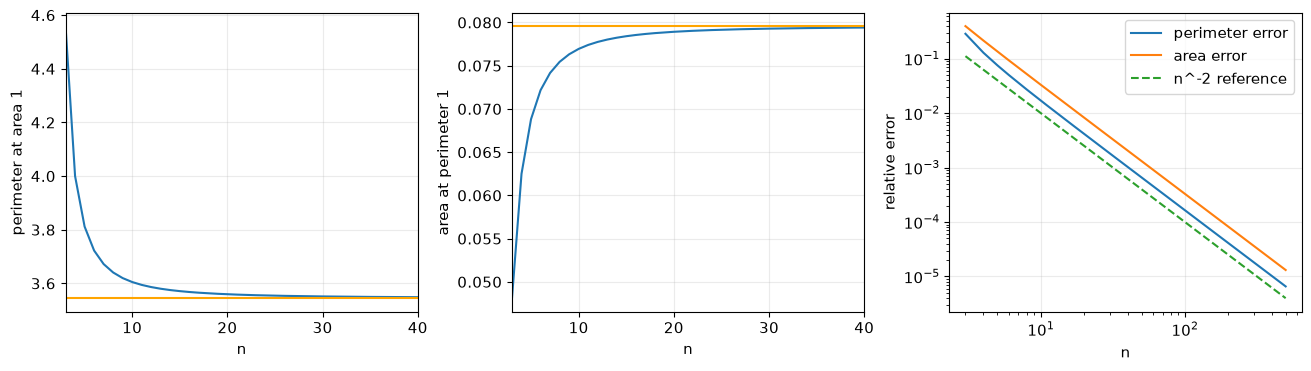

n=  3: P(area=1)=4.5590141, A(perimeter=1)=0.0481125
n=  4: P(area=1)=4.0000000, A(perimeter=1)=0.0625000
n=  6: P(area=1)=3.7224194, A(perimeter=1)=0.0721688
n= 12: P(area=1)=3.5863019, A(perimeter=1)=0.0777511
n=100: P(area=1)=3.5454910, A(perimeter=1)=0.0795513


In [3]:
ns = np.arange(3, 501)
result = regular_sequences(ns)
if result is None:
    print('Complete regular_sequences, then rerun this cell.')
else:
    perimeters, areas = result
    p_disk, a_disk = 2*np.sqrt(np.pi), 1/(4*np.pi)
    assert np.all(np.diff(perimeters) < 0) and np.all(np.diff(areas) > 0)
    p_error, a_error = perimeters/p_disk-1, 1-areas/a_disk
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
    ax[0].plot(ns, perimeters); ax[0].axhline(p_disk, color='orange')
    ax[0].set(xlabel='n', ylabel='perimeter at area 1', xlim=(3,40))
    ax[1].plot(ns, areas); ax[1].axhline(a_disk, color='orange')
    ax[1].set(xlabel='n', ylabel='area at perimeter 1', xlim=(3,40))
    ax[2].loglog(ns,p_error,label='perimeter error'); ax[2].loglog(ns,a_error,label='area error')
    ax[2].loglog(ns,1/ns.astype(float)**2,'--',label='n^-2 reference')
    ax[2].set(xlabel='n',ylabel='relative error'); ax[2].legend(); plt.show()
    p_scaled, a_scaled = regular_sequences(ns, A0=9., L=5.)
    np.testing.assert_allclose(p_scaled, 3*perimeters)
    np.testing.assert_allclose(a_scaled, 25*areas)
    for n in (3,4,6,12,100):
        p,a = regular_sequences([n])
        print(f'n={n:3d}: P(area=1)={p[0]:.7f}, A(perimeter=1)={a[0]:.7f}')


**Explain your observations.** Why does monotonic improvement inside the regular-polygon family not by itself establish the inequality for arbitrary shapes?

**Solution guidance:** Regular polygons improve monotonically within their own family. The leading relative perimeter error is π²/(6n²), and the relative area deficit is π²/(3n²). Passing from arbitrary shapes to the bound requires the polygonal inequality and approximation argument, not the table alone.

## Exercise 5.2: Dido: the shoreline is free

Take a half-ellipse $\gamma(\theta)=(\cos\theta,r\sin\theta)$,
$0\leq\theta\leq\pi$, above the shoreline $y=0$. Approximate its
free boundary by `segments` chords. Scale the entire figure so that
the **sum of free chord lengths** is $L=10$.

**Code tasks (35–45 minutes).**
1. Complete `dido_candidate(ratio, segments, L)`. Do not include the
   shoreline chord when imposing the free-boundary length constraint.
2. Close the chain with the shoreline **when computing area**. Return the
   scaled points and their enclosed area.
3. Search ratios from 0.4 to 2.5 on a logarithmic grid including 1.
   Repeat at 16, 64 and 256 segments. Plot area versus ratio and the
   winning polygonal chain. Compare with the continuous bound $L^2/(2\pi)$.

**Return contract:** `(chain, enclosed_area)`; the chain contains both
shoreline endpoints. Only the ratio parameter is searched. The discrete
optimum may shift slightly from the semicircle ratio at finite resolution.


In [4]:
def dido_candidate(ratio, segments, L=10.):
    theta = np.linspace(0,np.pi,segments+1)
    chain = np.column_stack([np.cos(theta),ratio*np.sin(theta)])
    free_length = np.linalg.norm(np.diff(chain,axis=0),axis=1).sum()
    chain *= L/free_length
    return chain, area(chain)


**Run, visualize and check.** Adapt these plots as requested, and report what changes when you refine the discretization or vary parameters.

 16 segments: best ratio=1.00000, gap=0.0511656
 64 segments: best ratio=1.00000, gap=0.00319592
256 segments: best ratio=1.00000, gap=0.000199738


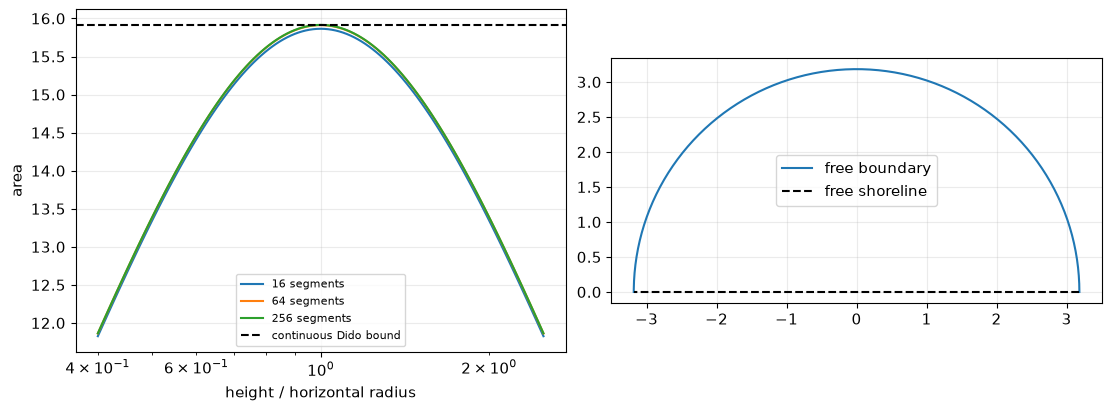

In [5]:
L = 10.
result = dido_candidate(1., 64, L)
if result is None:
    print('Complete dido_candidate, then rerun this cell.')
else:
    ratios = np.unique(np.r_[np.geomspace(.4,2.5,121),1.])
    bound = L**2/(2*np.pi)
    fig, ax = plt.subplots(1, 2, figsize=(11,4))
    for segments in (16,64,256):
        values = np.array([dido_candidate(r,segments,L)[1] for r in ratios])
        k = values.argmax()
        ax[0].plot(ratios,values,label=f'{segments} segments')
        assert values.max() <= bound+1e-10
        print(f'{segments:3d} segments: best ratio={ratios[k]:.5f}, gap={bound-values[k]:.6g}')
    chain, value = dido_candidate(ratios[k],256,L)
    np.testing.assert_allclose(np.linalg.norm(np.diff(chain,axis=0),axis=1).sum(),L)
    assert perimeter(chain) > L  # This includes the shoreline and is NOT the constraint.
    assert bound-value < 0.002
    ax[0].axhline(bound,color='black',ls='--',label='continuous Dido bound')
    ax[0].set(xlabel='height / horizontal radius',ylabel='area',xscale='log'); ax[0].legend(fontsize=8)
    ax[1].plot(chain[:,0],chain[:,1],label='free boundary')
    ax[1].plot(chain[[0,-1],0],[0,0],'k--',label='free shoreline')
    ax[1].set_aspect('equal'); ax[1].legend(); plt.show()


**Explain your observations.** Why is the area bound L²/(2π), rather than L²/(4π)? Identify the family restriction, the parameter grid and the boundary discretization as three separate approximations.

**Solution guidance:** Reflecting across the free shoreline doubles the area and gives a closed perimeter 2L, leading to A≤L²/(2π). The shoreline contributes to the area closure but not the free length budget. Family restriction, ratio sampling and chord approximation are three separate sources of limitation.

**Before submitting:** restart the kernel, run all cells in order, check axis labels and units, and explain any discrepancy between numerical and exact quantities.